# Fase 1: Limpieza de Datos y Análisis Exploratorio (EDA)
## Sistema de Predicción de Factores de Riesgo en Adolescentes Salvadoreños (GSHS 2013)

**Propósito:** Este notebook tiene como objetivo realizar la ingesta del dataset original de la Encuesta Global de Salud Escolar (GSHS) de El Salvador de 2013, solucionar una anomalía crítica en el procesamiento de valores nulos, construir las variables objetivos (Targets) para las tareas de regresión y clasificación, y realizar un análisis exploratorio visual preliminar.

In [1]:
import sys
# Indicamos a Python que busque en la carpeta raíz
sys.path.append('../')

# Importamos tus funciones modulares
from src.preprocess import load_and_clean_survey, engineer_targets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Carga y limpieza automática (esta función YA hace el pd.read_csv por ti)
ruta_cruda = '../data/raw/SLV2013_Public_Use.csv'
df_crudo = load_and_clean_survey(ruta_cruda)

# 2. Creación automática del IMC y del Riesgo de Salud Mental
df = engineer_targets(df_crudo)

# 3. Verificamos que todo esté correcto
print(f"Dimensiones del dataset listo para EDA: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head(3)

Datos cargados y limpiados exitosamente. Dimensiones: (1915, 104)
Dimensiones del dataset listo para EDA: 1915 filas y 106 columnas.


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,qnfrvgg,qnpa7g,qnpe5g,qnc1g,qnc2g,weight,stratum,psu,IMC,Riesgo_Salud_Mental
0,4.0,1.0,1.0,1.57,47.0,1.0,2.0,1.0,1.0,1.0,...,2.0,2.0,2.0,NaN,NaN,256.3443,201301006,11,19.067711,0
1,3.0,1.0,1.0,1.57,51.0,3.0,2.0,2.0,4.0,2.0,...,2.0,2.0,2.0,NaN,NaN,256.3443,201301006,11,20.690495,0
2,4.0,1.0,1.0,1.63,49.0,2.0,3.0,1.0,2.0,1.0,...,2.0,2.0,2.0,NaN,NaN,256.3443,201301006,11,18.442546,0


## 1. Carga de Datos y Tratamiento de la Anomalía Crítica

**¿Qué hace este bloque?**
Carga el archivo CSV crudo y reemplaza de inmediato el valor `1.79769313486232e+308` por valores nulos reales (`np.nan`).

**¿Por qué lo hacemos así?**
Los datos extraídos de encuestas procesadas originalmente en softwares estadísticos como SPSS o Stata suelen codificar las respuestas vacías (missing values) con el número máximo permitido por un flotante de 64 bits (`1.79e+308`). Si dejamos este valor numérico en el dataset, cualquier operación estadística posterior (como calcular promedios, desviaciones estándar o entrenar modelos de Machine Learning) se corromperá debido a la magnitud extrema de esta cifra. Transformarlo en `NaN` nos permite usar las funciones nativas de limpieza de Pandas en los pasos siguientes.

In [2]:

# Identificación y reemplazo de la anomalía
valor_anomalo = 1.79769313486232e+308
df = df.replace(valor_anomalo, np.nan)

print("Anomalía extrema eliminada y reemplazada por valores nulos (np.nan).")

Anomalía extrema eliminada y reemplazada por valores nulos (np.nan).


## 2. Ingeniería de Variables: Construcción del Target A (Regresión - IMC)

**¿Qué hace este bloque?**
Calcula el Índice de Masa Corporal (IMC) para cada estudiante utilizando las variables originales de la encuesta: Peso (`Q5`) y Estatura (`Q4`).

**¿Por qué lo hacemos así?**
La rúbrica del desafío exige estimar el IMC basándose únicamente en variables de comportamiento (como alimentación, actividad física y horas en pantalla). La fórmula oficial de la OMS establece que:
$$IMC = \frac{Peso}{(Estatura)^2}$$
Calculamos el target en esta etapa para tener una variable continua de regresión. Es sumamente importante recalcar que en las fases de modelado eliminaremos `Q4` y `Q5` de los predictores para evitar el *Data Leakage* (fuga de datos), garantizando que el modelo aprenda de los patrones de conducta y no de las medidas físicas directas.

In [3]:
# Verificamos que las columnas de peso y estatura existan antes del cálculo
if 'Q5' in df.columns and 'Q4' in df.columns:
    df['IMC'] = df['Q5'] / (df['Q4'] ** 2)
    print("Variable objetivo 'IMC' creada exitosamente.")
    print(df['IMC'].describe())
else:
    print("Error: No se encontraron las columnas Q4 o Q5 en el dataset.")

Variable objetivo 'IMC' creada exitosamente.
count    1738.000000
mean       21.635691
std         4.144966
min        13.793103
25%        18.765247
50%        20.709409
75%        23.437500
max        46.777373
Name: IMC, dtype: float64


## 3. Ingeniería de Variables: Construcción del Target B (Clasificación - Riesgo de Salud Mental)

**¿Qué hace este bloque?**
Crea una variable binaria llamada `Riesgo_Salud_Mental` donde `1` representa presencia de riesgo grave y `0` representa ausencia del mismo, basándose en la variable `Q25` de la encuesta (ideación suicida o soledad/tristeza extrema).

**¿Por qué lo hacemos así?**
Para la tarea de clasificación orientada a políticas de prevención temprana del MINSAL, requerimos identificar un indicador crítico de salud mental. Evaluamos las respuestas de la pregunta elegida (donde tradicionalmente la respuesta 1 equivale a una consideración seria de ideación o tristeza recurrente) y mapeamos los valores para adaptarlos a una estructura binaria óptima para algoritmos de clasificación como Regresión Logística o XGBoost.

In [4]:
# Evaluamos y definimos la variable binaria. Usamos Q25 como indicador.
# Mapeamos de forma segura: si respondió '1' es un caso de riesgo (1), de lo contrario (0).
df['Riesgo_Salud_Mental'] = df['Q25'].apply(lambda x: 1 if x == 1 else 0)

# Mostramos la distribución de clases inicial
distribucion_clases = df['Riesgo_Salud_Mental'].value_counts(normalize=True) * 100
print("Distribución porcentual de la variable Riesgo_Salud_Mental:")
print(distribucion_clases)

Distribución porcentual de la variable Riesgo_Salud_Mental:
Riesgo_Salud_Mental
0    88.929504
1    11.070496
Name: proportion, dtype: float64


## 4. Análisis Exploratorio de Datos (EDA) Visual

**¿Qué hace este bloque?**
Genera gráficos para analizar las distribuciones univariadas del IMC calculado, la prevalencia del riesgo de salud mental en la muestra, y un análisis bivariado del IMC según los rangos de edad.

**¿Por qué lo hacemos así?**
El análisis visual nos permite validar la calidad de las variables construidas. Por ejemplo, el gráfico de barras de salud mental nos mostrará de manera explícita el nivel de desbalance de clases del dataset (la cantidad de jóvenes sin riesgo suele ser drásticamente superior a los que sí presentan riesgo). Esto nos servirá como justificación técnica en el informe para implementar soluciones de remuestreo como SMOTE o configuraciones de pesos ponderados en las fases de modelado de clasificación.

/tmp/ipykernel_392484/2118661633.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Riesgo_Salud_Mental', palette='Set1', ax=axes[1])
/tmp/ipykernel_392484/2118661633.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Q1', y='IMC', palette='Set3', ax=axes[2])


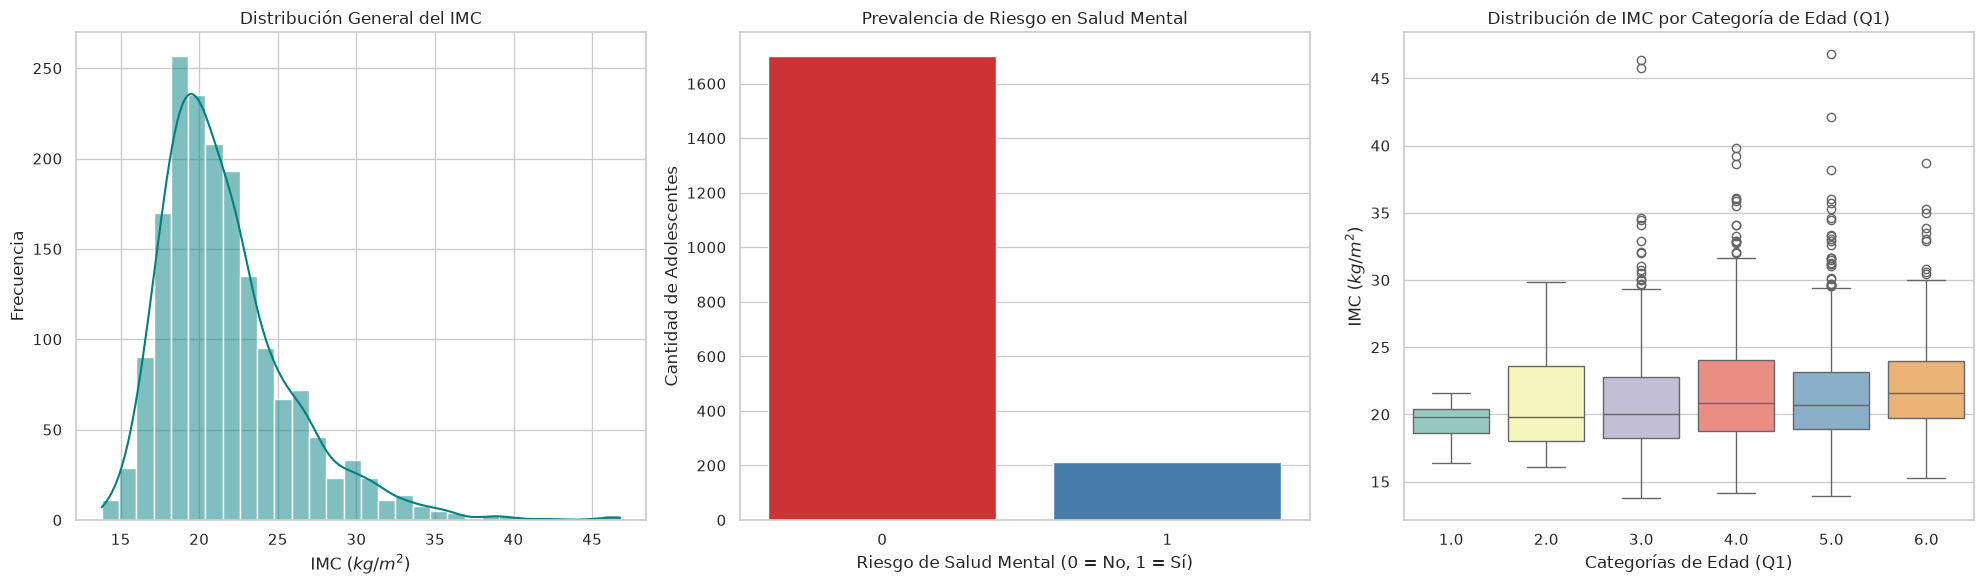

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: Histograma del IMC para evaluar asimetría y outliers
sns.histplot(df['IMC'].dropna(), kde=True, bins=30, color='teal', ax=axes[0])
axes[0].set_title('Distribución General del IMC')
axes[0].set_xlabel('IMC ($kg/m^2$)')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Countplot para constatar visualmente el desbalance de clases en Salud Mental
sns.countplot(data=df, x='Riesgo_Salud_Mental', palette='Set1', ax=axes[1])
axes[1].set_title('Prevalencia de Riesgo en Salud Mental')
axes[1].set_xlabel('Riesgo de Salud Mental (0 = No, 1 = Sí)')
axes[1].set_ylabel('Cantidad de Adolescentes')

# Gráfico 3: Boxplot bivariado para examinar cómo varía el IMC respecto a las categorías de edad (Q1)
sns.boxplot(data=df, x='Q1', y='IMC', palette='Set3', ax=axes[2])
axes[2].set_title('Distribución de IMC por Categoría de Edad (Q1)')
axes[2].set_xlabel('Categorías de Edad (Q1)')
axes[2].set_ylabel('IMC ($kg/m^2$)')

plt.tight_layout()
plt.show()

## 5. Exportación del Dataset Limpio

**¿Qué hace este bloque?**
Exporta el estado actual del DataFrame con los datos limpios y las dos nuevas columnas objetivos creadas a la carpeta de almacenamiento de datos procesados (`data/processed/`).

**¿Por qué lo hacemos así?**
De acuerdo con las buenas prácticas de la arquitectura de software del proyecto, debemos aislar los datos crudos e inmutables de los conjuntos de datos modificados. Guardar este archivo intermedio nos permite iniciar el siguiente notebook de Ingeniería de Características (Feature Engineering) de forma independiente, asegurando la modularidad del pipeline de trabajo sin necesidad de volver a ejecutar todo el proceso de limpieza visual inicial.

In [6]:
# Ruta de guardado para los datos limpios
ruta_procesada = '../data/processed/SLV2013_Limpios_Targets.csv'

# Almacenamiento seguro en disco
df.to_csv(ruta_procesada, index=False)

print(f"Éxito: Dataset exportado correctamente a '{ruta_procesada}'")
print(f"El archivo está listo con {df.shape[0]} registros para la siguiente etapa de Feature Engineering.")

Éxito: Dataset exportado correctamente a '../data/processed/SLV2013_Limpios_Targets.csv'
El archivo está listo con 1915 registros para la siguiente etapa de Feature Engineering.
